In [1]:
#Libraries and Modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [2]:
#Load PCA Dataset
df_pca = pd.read_csv("pca_dataset.csv")

In [3]:
#Feature Seperation
PC = df_pca.drop(
    columns=["target_actual"]
)

In [4]:
#GMM (comp = 2)
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)
gmm.fit(PC)
probs = gmm.predict_proba(PC)
df_pca["Components"] =  gmm.predict(PC)

In [5]:
#Crosstab
pd.crosstab(
    df_pca["target_actual"],
    df_pca["Components"]
)

Components,0,1
target_actual,,
normal breast tissue,0,11
primary breast cancer,59,63


In [6]:
#Silhouette Score 2 components
gmm_score = silhouette_score(PC, df_pca["Components"])
gmm_score

0.22040662650891107

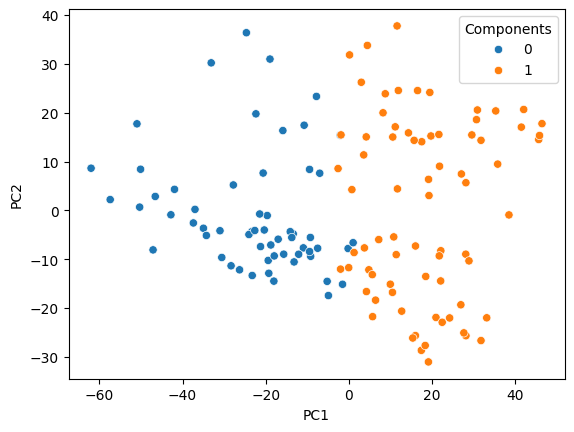

In [8]:
#Cluster Visualization
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Components"
)
plt.savefig(
    "screenshots/GMM cluster visualization",
    dpi=300,
    bbox_inches="tight"
    )

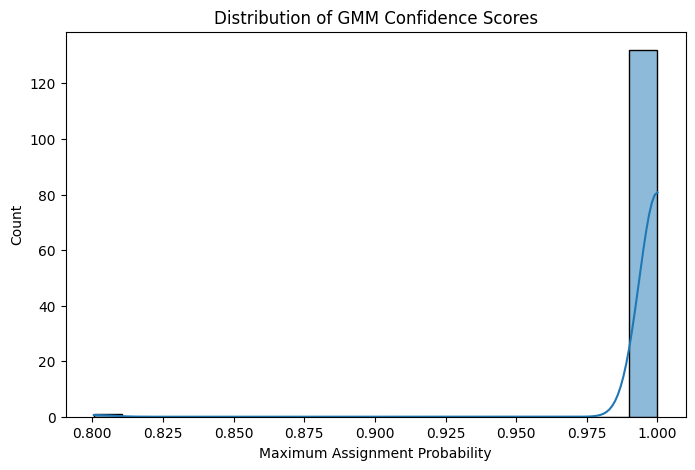

In [12]:
#Confidence distribution
max_prob = probs.max(axis=1)

plt.figure(figsize=(8,5))

sns.histplot(
    max_prob,
    bins=20,
    kde=True
)

plt.xlabel("Maximum Assignment Probability")
plt.ylabel("Count")
plt.title("Distribution of GMM Confidence Scores")
plt.savefig(
    "screenshots/Confidence Histogram",
    dpi=300,
    bbox_inches="tight"
    )

plt.show()

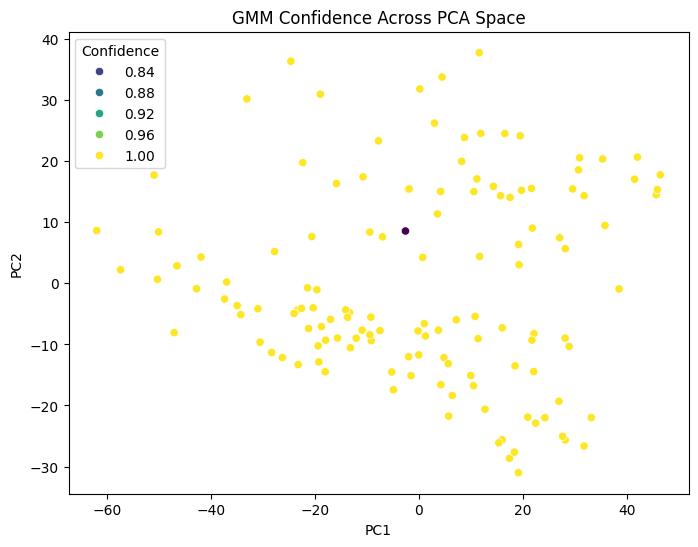

In [14]:
#Confidence on PCA plot
df_pca["Confidence"] = max_prob

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Confidence",
    palette="viridis"
)

plt.title("GMM Confidence Across PCA Space")
plt.savefig(
    "screenshots/Confidence PCA plot",
    dpi=300,
    bbox_inches="tight"
    )

plt.show()

In [32]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

results = []

for n in range(2,11):

    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )

    labels = gmm.fit_predict(PC)

    results.append({
        "Components": n,
        "Silhouette": silhouette_score(PC, labels),
        "AIC": gmm.aic(PC),
        "BIC": gmm.bic(PC)
    })

results_df = pd.DataFrame(results)
results_df

,Components,Silhouette,AIC,BIC
0,2,0.220407,24051.899632,27291.981005
1,3,0.235456,22012.857867,26874.425101
2,4,0.245176,19772.375097,26255.428192
3,5,0.252619,14197.262790,22301.801745
4,6,0.263220,8768.087962,18494.112778
5,7,0.253649,7534.443638,18881.954315
6,8,0.243023,1577.669109,14546.665647
7,9,0.249707,237.235198,14827.717597
8,10,0.250860,709.718886,16921.687146
